In [1]:
suppressPackageStartupMessages({
library(Seurat)
library(SeuratData)
library(tidyverse)
library(pheatmap)
library(RColorBrewer)
library(ggbeeswarm)
library(cowplot)
library(ggcompare)
library(compositions)
library(DirichletReg)
})
theme_set(theme_cowplot())
options(repr.plot.width=15, repr.plot.height=9, width=120)

# Compositional data difference test

# data

In [2]:
panc8 <- suppressMessages(LoadData("panc8"))
panc8

Warning message:
"Assay RNA changing from Assay to Assay"
Warning message:
"Assay RNA changing from Assay to Assay5"


An object of class Seurat 
34363 features across 14890 samples within 1 assay 
Active assay: RNA (34363 features, 0 variable features)
 2 layers present: counts, data

In [3]:
panc8@meta.data |>
head()

,orig.ident,nCount_RNA,nFeature_RNA,tech,replicate,assigned_cluster,celltype,dataset
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
D101_5,D101,4615.810,1986,celseq,celseq,NA,gamma,celseq
D101_7,D101,29001.563,4209,celseq,celseq,NA,acinar,celseq
D101_10,D101,6707.857,2408,celseq,celseq,NA,alpha,celseq
D101_13,D101,8797.224,2964,celseq,celseq,NA,delta,celseq
D101_14,D101,5032.558,2264,celseq,celseq,NA,beta,celseq
D101_17,D101,13474.866,3982,celseq,celseq,NA,ductal,celseq


In [4]:
metadata <-
    panc8@meta.data |>
    distinct(orig.ident, tech) |>
    as_tibble()
head(metadata)

orig.ident,tech
<chr>,<chr>
D101,celseq
D102,celseq
D10631,celseq
D1713,celseq
D172444,celseq
D17All1,celseq


# Counts

This is a pancreatic single cell dataset consisting of 65 samples, 13 different cell types, measured with 5 different techniques.

Here, we will ignore the gene expression, and just look at the cell composition of each sample/tech.

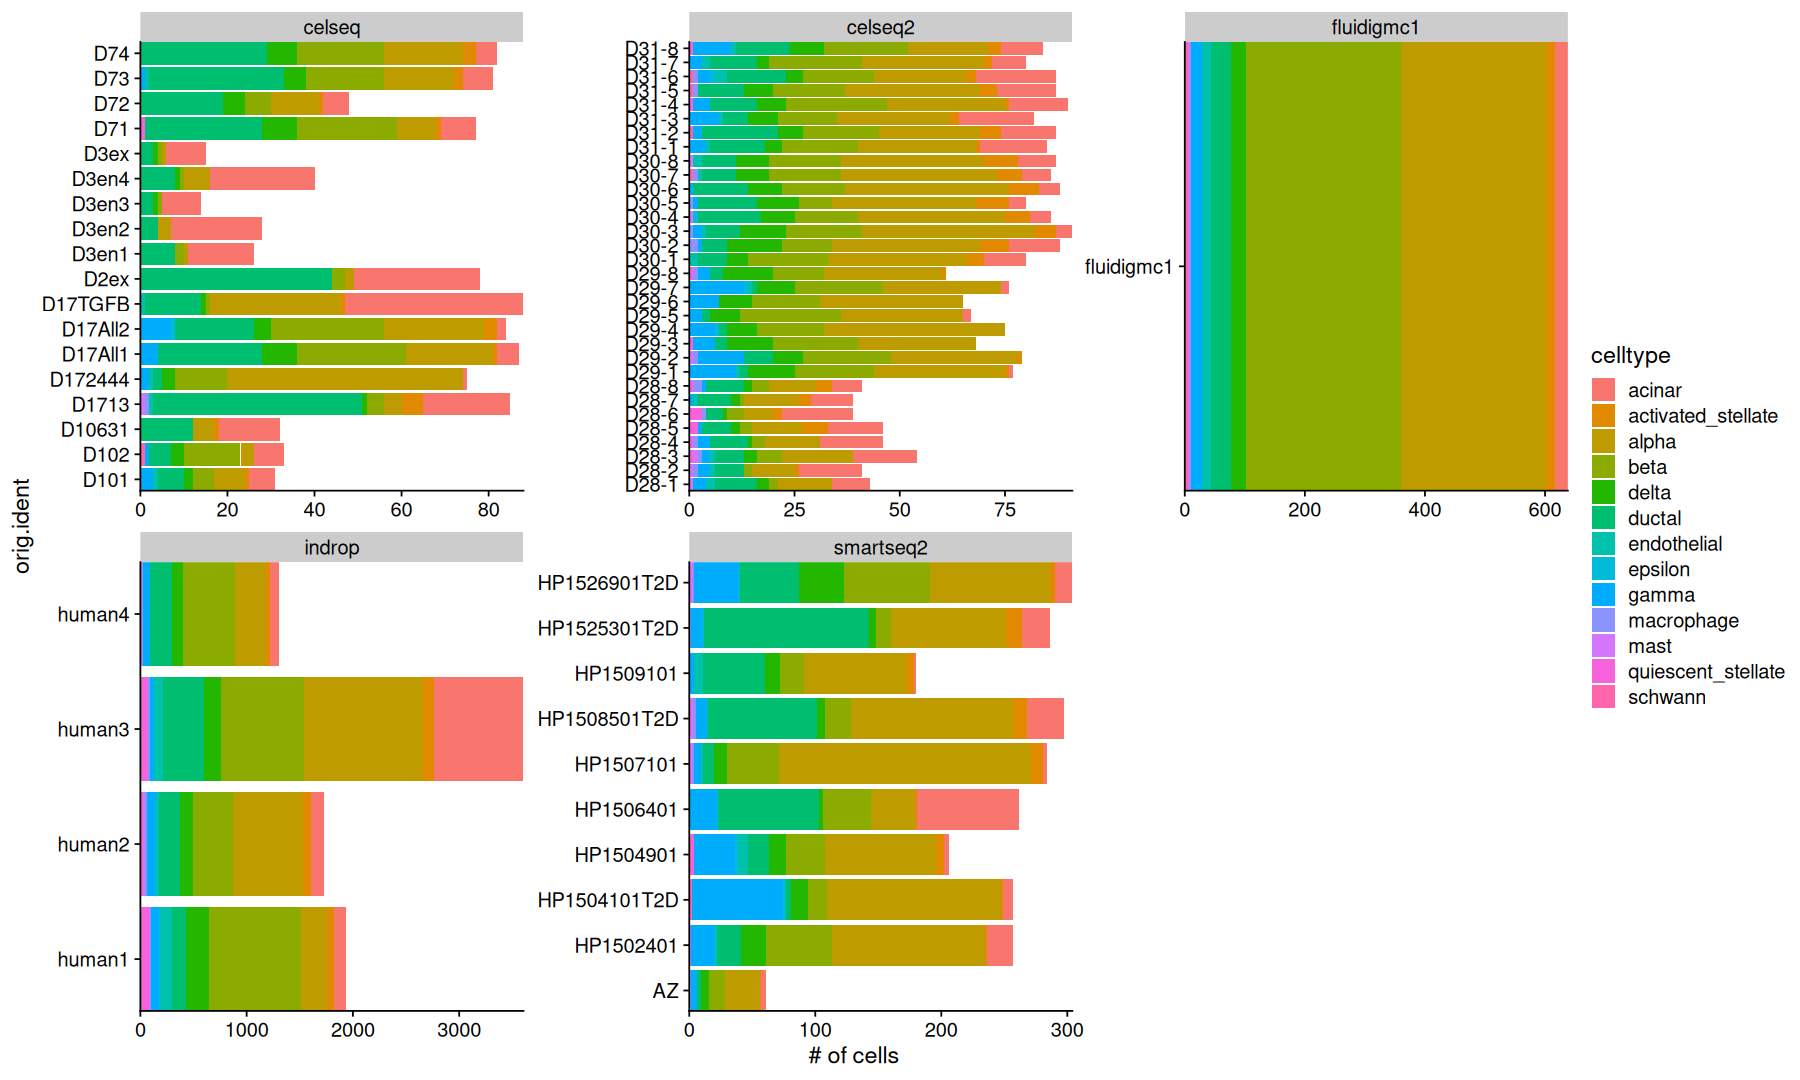

In [5]:
panc8@meta.data |>
count(orig.ident, celltype, tech) |>
ggplot(aes(y=orig.ident, x=n, fill=celltype)) + 
geom_col() +
labs(x='# of cells') +
facet_wrap(~tech, scales='free') +
coord_cartesian(expand=0)

Counts are the simplest way to look at the data.

However, differences in the total number of cells between samples and techniques aren't relevant to us.

In [6]:
ncells_mtx <-
    panc8@meta.data |>
    # I am combining celltypes with low amount of cells into "other"
    # this is just for illustration purposes
    mutate(ct2 = ifelse(celltype %in% c('epsilon','schwann','mast','macrophage','quiescent_stellate','endothelial'), 'other', celltype)) |>
    count(orig.ident, ct2) |>
    pivot_wider(names_from = ct2, values_from = n, values_fill = 0) |>
    column_to_rownames('orig.ident')

In [7]:
ncells_mtx[1:5,]; sum(ncells_mtx)

,acinar,activated_stellate,alpha,beta,delta,ductal,gamma,other
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
AZ,4,1,28,12,7,3,5,1
D101,6,1,7,5,2,6,3,1
D102,7,0,3,13,3,5,1,1
D10631,14,1,5,0,0,12,0,0
D1713,20,5,4,4,1,48,0,3


[1] 14890

In [8]:
colSums(ncells_mtx)

acinar activated_stellate              alpha               beta              delta             ductal 
              1864                474               4615               3679               1013               1954 
             gamma              other 
               625                666

# Percentages

Percentages uses the sum of the cells in each sample as the normalizing denominator, so that each row will sum to 1.

The "acomp" function is part of the compositions package, and does this normalization for us.

In [9]:
summary(rowSums(acomp(ncells_mtx)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       1       1       1       1       1 

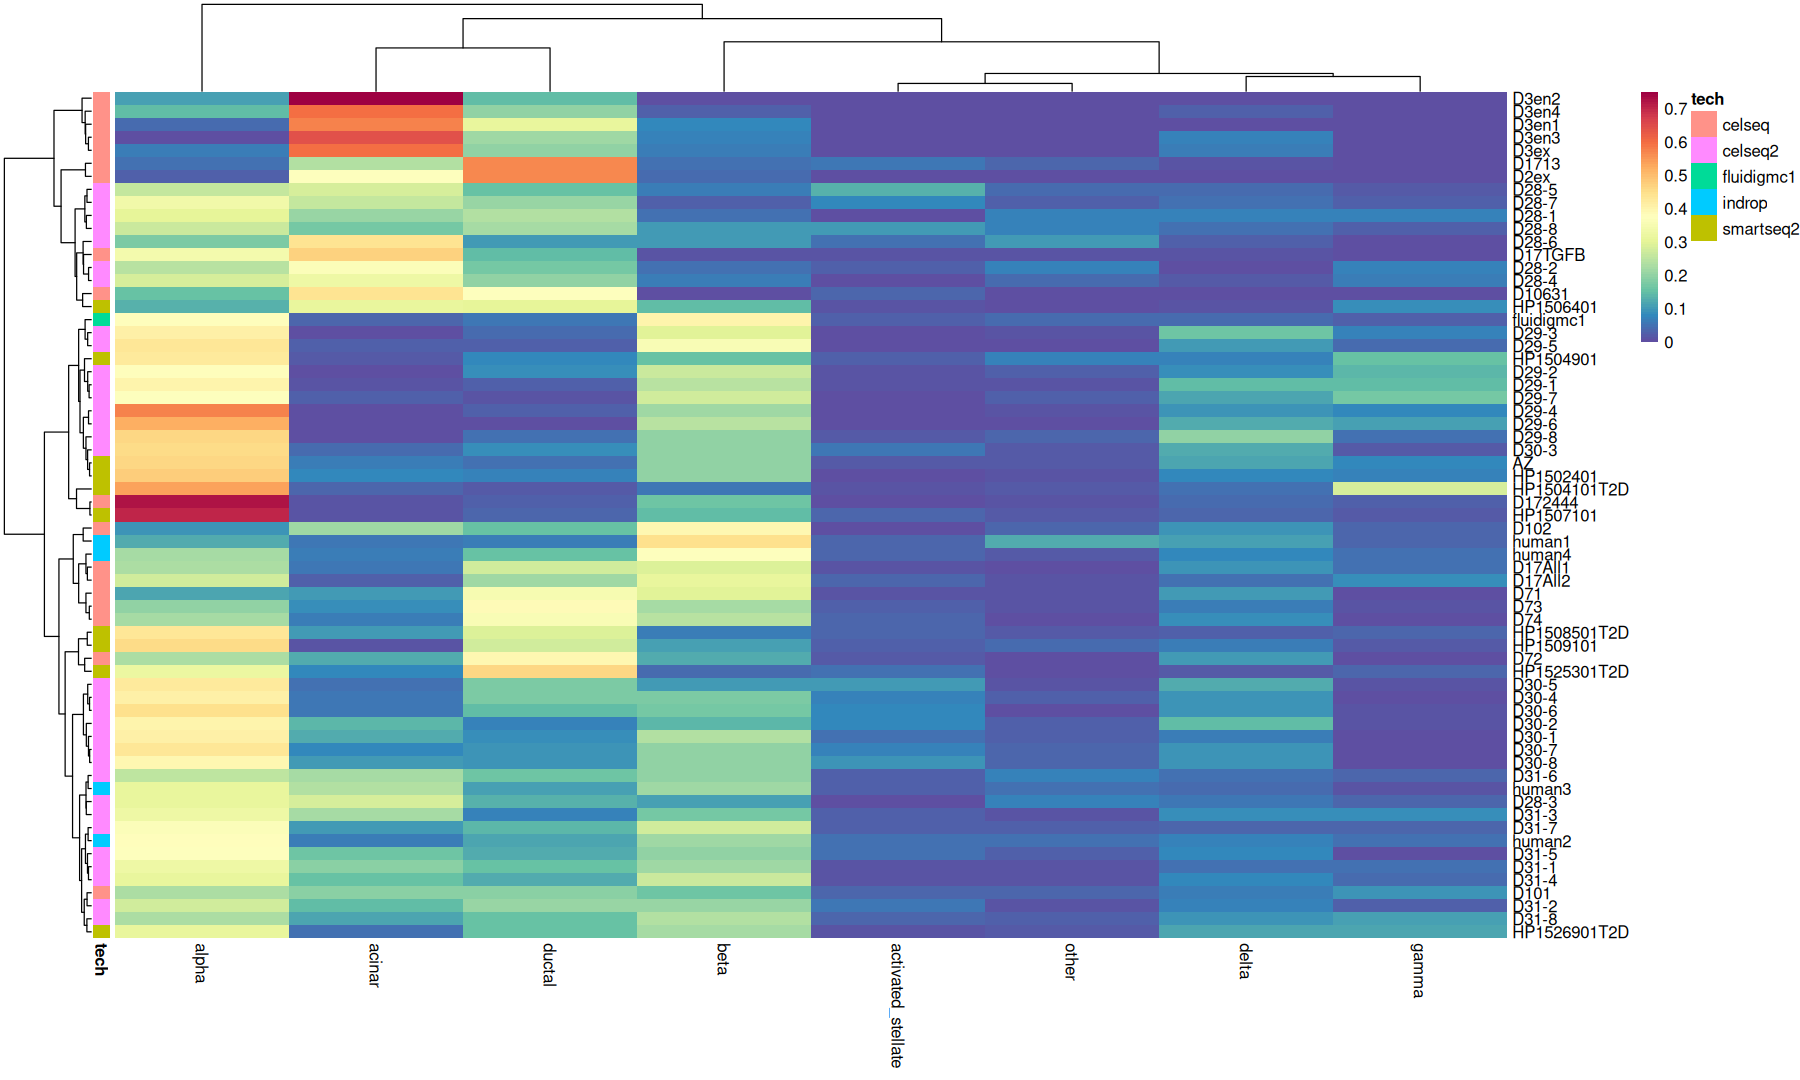

In [10]:
color_p = colorRampPalette(rev(brewer.pal('Spectral', n=11)))(100)
acomp(ncells_mtx) |>
pheatmap(
    color=color_p,
    clustering_method='ward.D2',
    clustering_disttance_rows='canberra',
    clustering_disttance_cols='canberra',
    annotation_row=column_to_rownames(metadata, 'orig.ident'),
    border_color=NA
)

# Difference test

To compare the proportions between cell types, we can use a statistical test.

In [11]:
comparisons <- combn(unique(metadata$tech), 2, simplify = FALSE)

In [12]:
test_func <- function(...) {
    r = wilcox.test(..., exact=FALSE)
    list(p.value=r$p.value, method='wilcox.test')
}

Warning message:
"Removed 67 rows containing missing values or values outside the scale range (`geom_bracket()`)."


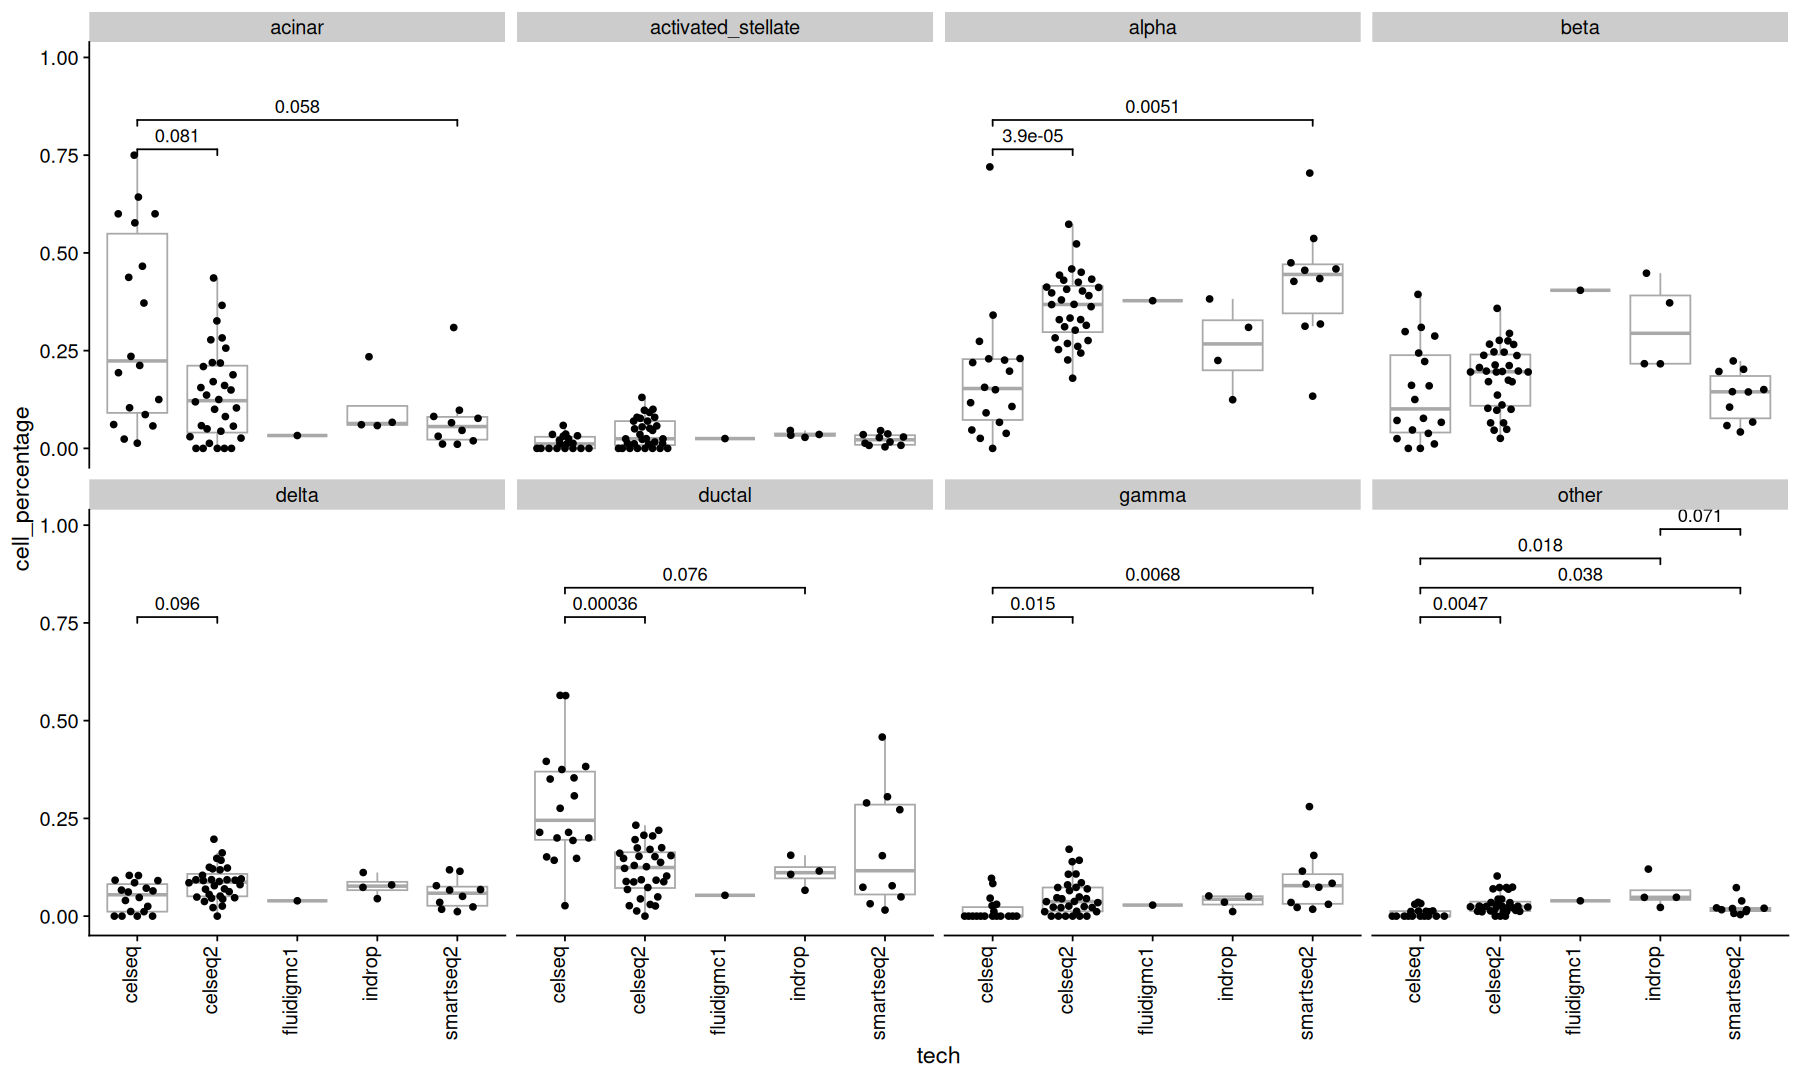

In [13]:
acomp(ncells_mtx) |>
as.data.frame() |>
rownames_to_column('orig.ident') |>
pivot_longer(names_to = 'celltype', values_to = 'cell_percentage', cols=-orig.ident) |>
inner_join(metadata, by='orig.ident') |>
ggplot(aes(x=tech, y=cell_percentage)) +
geom_boxplot(color='darkgray', outlier.shape = NA) +
geom_quasirandom() +
stat_compare(comparisons = comparisons, correction = 'fdr', cutoff=0.1, panel_indep = TRUE, method=test_func) +
theme(axis.text.x=element_text(angle=90, vjust=0, hjust=1)) +
facet_wrap(~celltype, ncol=4)

Many cell types show significant pvalues, but since the cell types are parts of a whole, its difficult to attribute this change to a specific cell type.

# clr transform

The clr transform uses the geometric mean of the subsets as the denominator.

the clr() function is also part of the compositions package.

Warning message:
"Removed 76 rows containing missing values or values outside the scale range (`geom_bracket()`)."


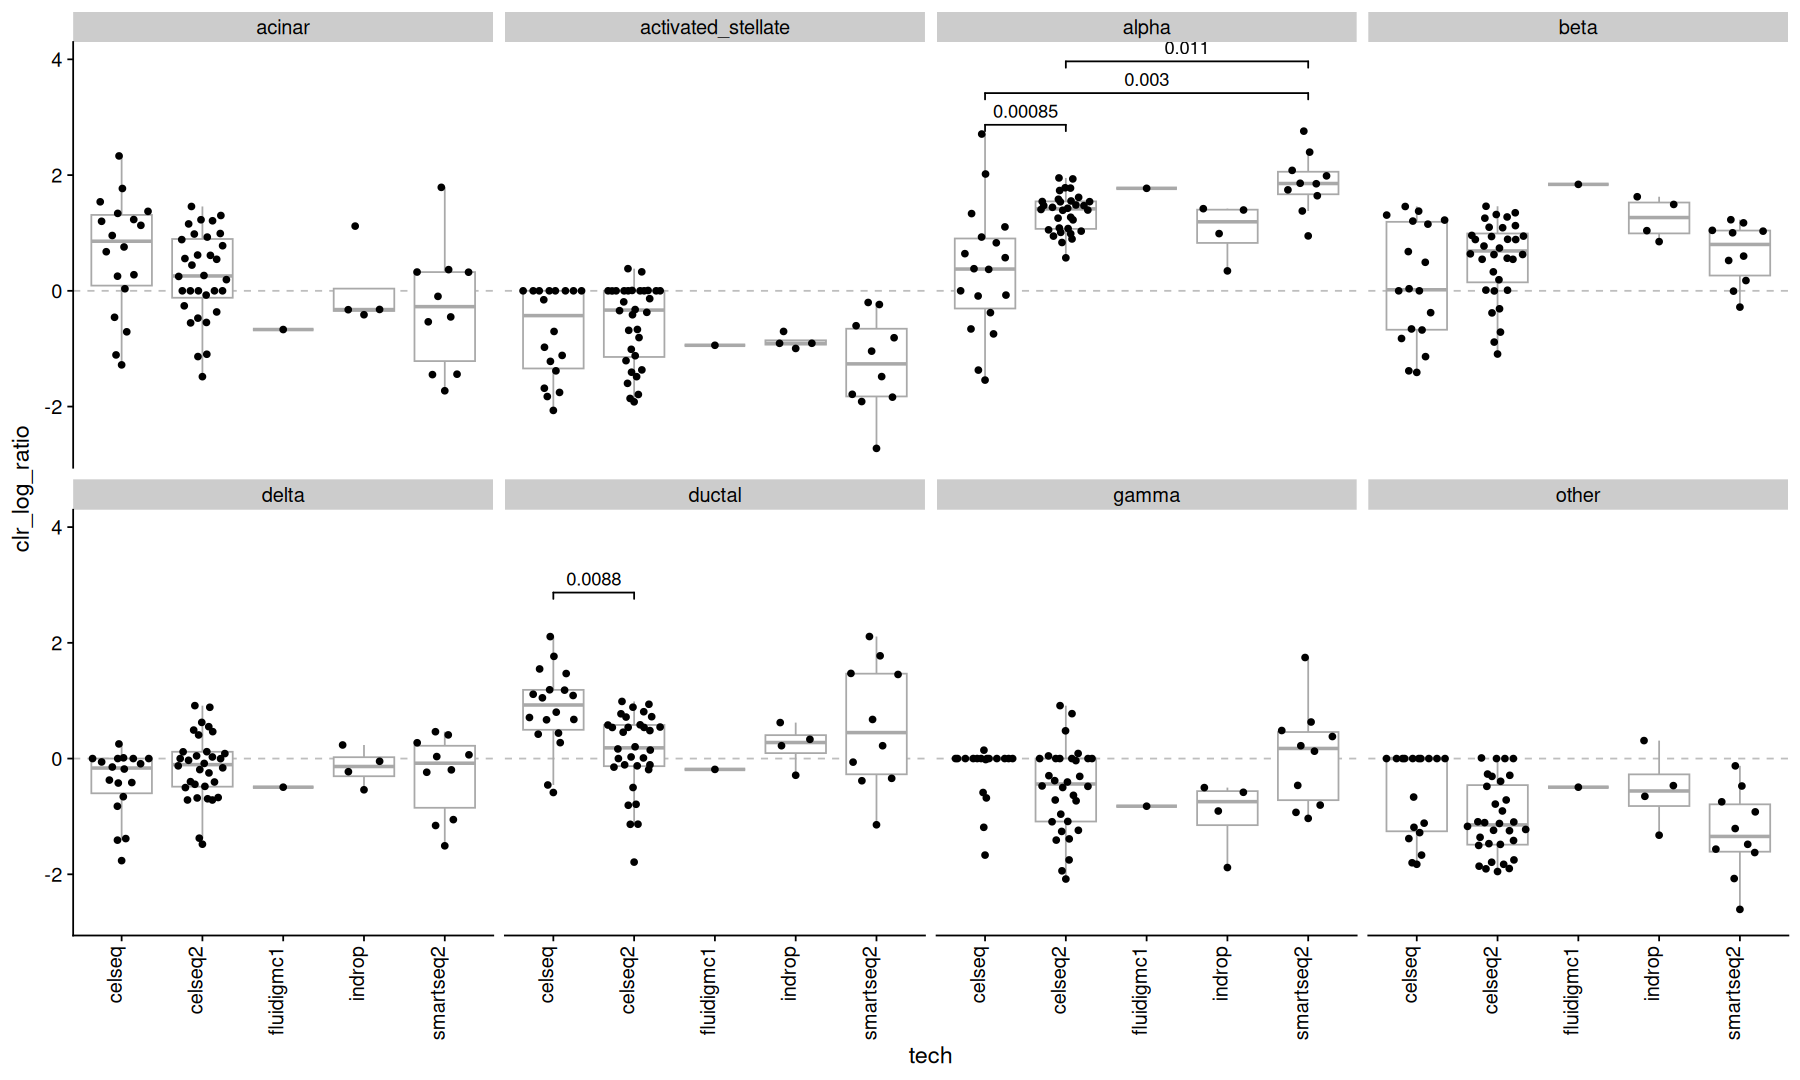

In [14]:
acomp(ncells_mtx) |>
clr() |>
as.data.frame() |>
rownames_to_column('orig.ident') |>
pivot_longer(names_to = 'celltype', values_to = 'clr_log_ratio', cols=-orig.ident) |>
inner_join(metadata, by='orig.ident') |>
ggplot(aes(x=tech, y=clr_log_ratio)) +
geom_hline(yintercept=0, color='gray', linetype=2) +
geom_boxplot(color='darkgray', outlier.shape = NA) +
geom_quasirandom() +
stat_compare(comparisons = comparisons, correction = 'fdr', cutoff=0.1, panel_indep=TRUE, method=test_func) +
theme(axis.text.x=element_text(angle=90, vjust=0, hjust=1)) +
facet_wrap(~celltype, ncol=4)

notice how many of the significant pvalues disappeared.

# alr transform

The alr transform uses a specified subset as the denominator, here the cell type "other" was used.

Warning message:
"Removed 113 rows containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 113 rows containing non-finite outside the scale range (`stat_compare()`)."
Warning message:
"Removed 26 rows containing missing values or values outside the scale range (`position_quasirandom()`)."
Warning message:
"Removed 87 rows containing missing values or values outside the scale range (`geom_point()`)."
Warning message:
"Removed 67 rows containing missing values or values outside the scale range (`geom_bracket()`)."


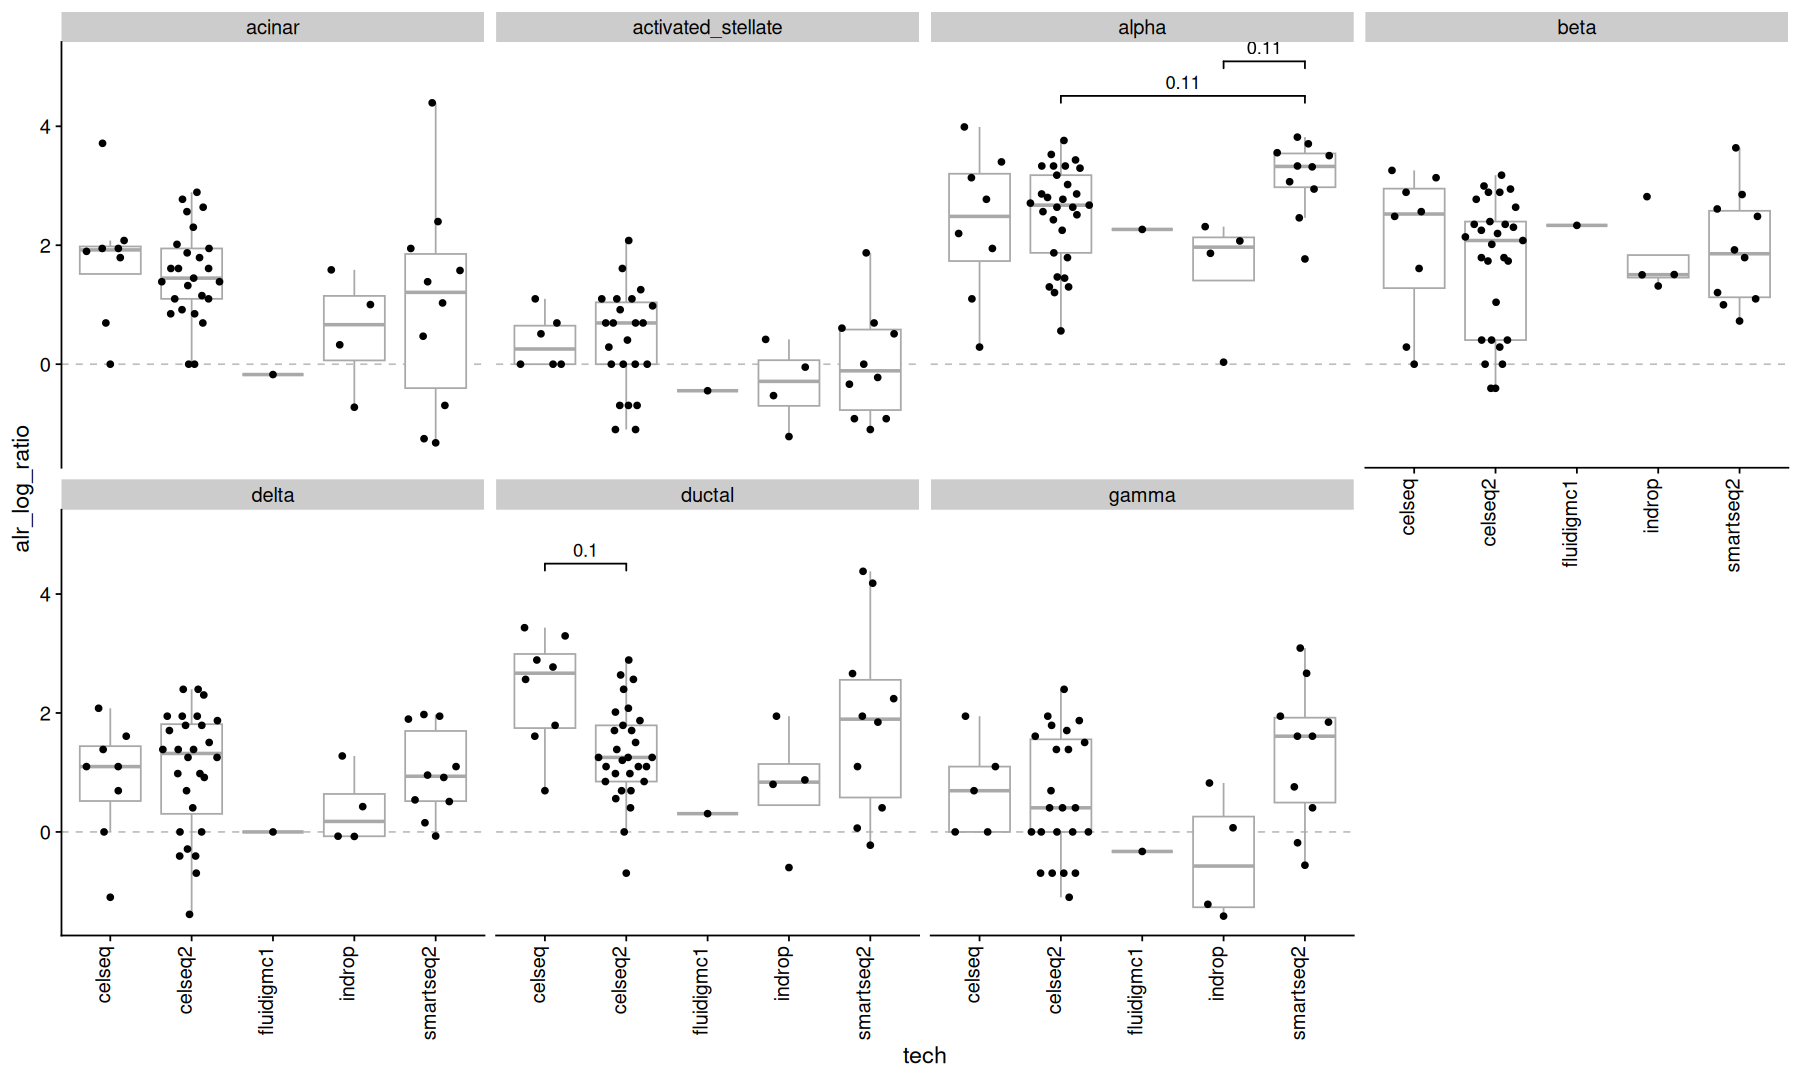

In [15]:
acomp(ncells_mtx) |>
alr(ivar='other') |> # using celltype 'other' as the denominator
as.data.frame() |>
rownames_to_column('orig.ident') |>
pivot_longer(names_to = 'celltype', values_to = 'alr_log_ratio', cols=-orig.ident) |>
inner_join(metadata, by='orig.ident') |>
ggplot(aes(x=tech, y=alr_log_ratio)) +
geom_hline(yintercept=0, color='gray', linetype=2) +
geom_boxplot(color='darkgray', outlier.shape = NA) +
geom_quasirandom() +
stat_compare(comparisons = comparisons, correction = 'fdr', cutoff=0.2, panel_indep = TRUE, method=test_func) +
theme(axis.text.x=element_text(angle=90, vjust=0, hjust=1)) +
facet_wrap(~celltype, ncol=4)

No cell types show significant (<0.1) pvalues here. 

but remember to think carefully about which subset to use as the denominator.

# Dirichlet regression

The Dirichlet distribution models the probability of a multinomial random variable that sums to 1.

It provides an alternative to log-ratio regression for the modeling of compositional data.

In [16]:
meta <- filter(metadata, tech != 'fluidigmc1') # remove outlier

z <- ncells_mtx[meta$orig.ident,] 
z <- z/rowSums(z)

all(rownames(z) == meta$orig.ident) # make sure its in the same order

[1] TRUE

In [17]:
dr <- DR_data(z)
summary(rowSums(dr))

Warning message in DR_data(z):
"some entries are 0 or 1 => transformation forced"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       1       1       1       1       1 

Note that the Dirichlet distribution can't model zeroes or ones, so a transformation was applied in these cases.

In [18]:
reg <- DirichReg(dr ~ tech - 1, meta)
reg

Call:
DirichReg(formula = dr ~ tech - 1, data = meta)
using the common parametrization

Log-likelihood: 771.9 on 32 df (105 BFGS + 1 NR Iterations)

-----------------------------------------
Coefficients for variable no. 1: acinar
   techcelseq    techcelseq2     techindrop  techsmartseq2  
       0.6371         0.3604         1.4701         0.2580  
-----------------------------------------
Coefficients for variable no. 2: activated_stellate
   techcelseq    techcelseq2     techindrop  techsmartseq2  
      -0.9922        -0.3468         0.7442        -0.2810  
-----------------------------------------
Coefficients for variable no. 3: alpha
   techcelseq    techcelseq2     techindrop  techsmartseq2  
       0.2472         1.7536         2.4029         1.9901  
-----------------------------------------
Coefficients for variable no. 4: beta
   techcelseq    techcelseq2     techindrop  techsmartseq2  
     -0.04158        1.05837        2.60706        0.92925  
--------------------------

In [19]:
tidy_dr <- function(dr_reg, exp=FALSE) {
    w = confint(dr_reg, exp=exp)
    map_df(1:length(w$coefficients), function(i) {
        if(exp) {
            cc <- base::exp(w$coefficients[[i]])
        } else {
            cc <- w$coefficients[[i]]
        }
        as.data.frame(w$ci[[1]][[i]]) |>
        rownames_to_column('term') |>
        rename(ci.low=V1, ci.high=V2) |>
        mutate(
            subset=names(w$coefficients)[[i]]
        ) |>
        inner_join(as_tibble(cc,rownames = 'term'), by='term')
    })
}

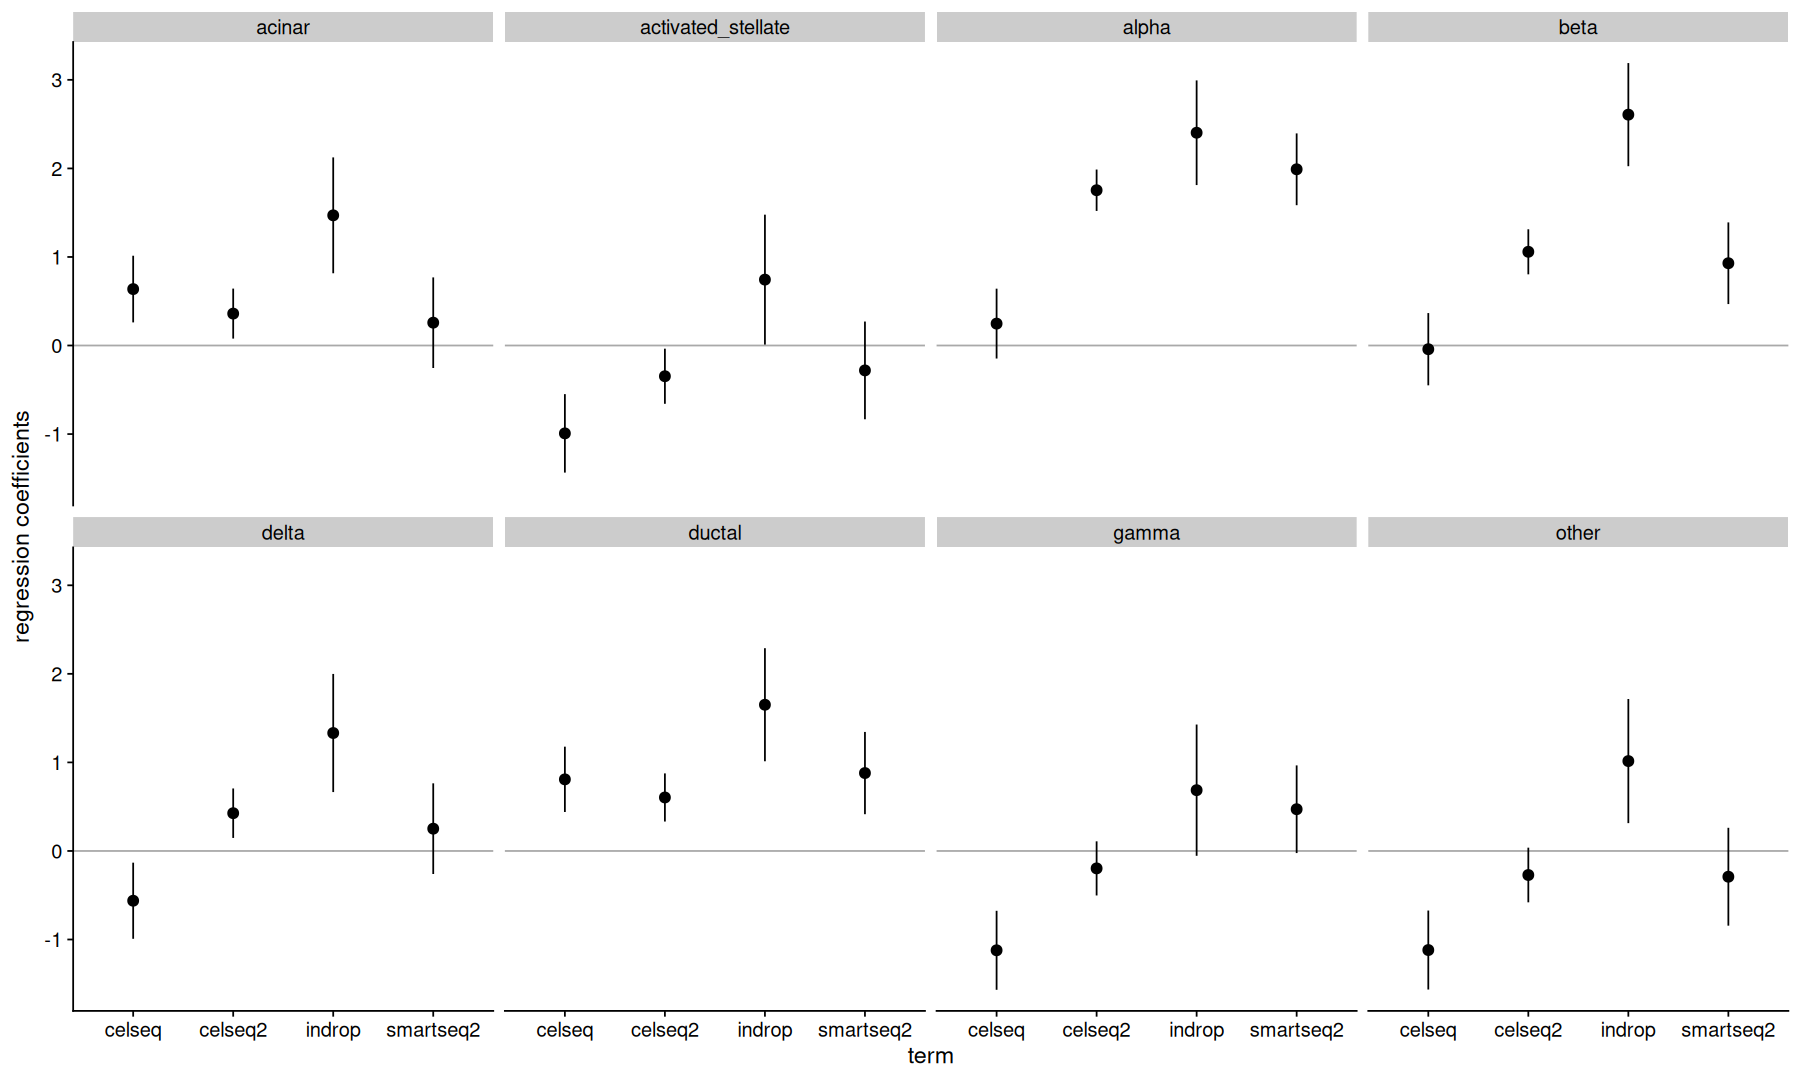

In [20]:
tidy_dr(reg, exp=FALSE) |>
mutate(term=gsub('tech','', term)) |>
ggplot(aes(x=term, y=value)) +
geom_hline(yintercept=0, color='darkgray') +
geom_point() +
geom_pointrange(aes(ymin=ci.low, ymax=ci.high)) +
facet_wrap(~subset, ncol=4) +
labs(y='regression coefficients')

# Further reading

https://en.wikipedia.org/wiki/Compositional_data

https://en.wikipedia.org/wiki/Dirichlet_distribution

http://www.stat.boogaart.de/compositions/

https://www.geo.fu-berlin.de/en/v/soga-r/Advances-statistics/Feature-scales/Intro_compositional_data/index.html

http://www.csam.or.kr/journal/view.html?doi=10.29220/CSAM.2022.29.4.453

https://ijbnpa.biomedcentral.com/articles/10.1186/s12966-018-0685-1